<h1 align="center">ใบงานที่ 3 Regression & Classification</h1>

## LAB 3: Model Comparison 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

# Load Dataset
df = pd.read_csv('Dataset.csv')

# Prepare Regression Data (Predicting Bounty)
df_reg = df.dropna(subset=['Bounty']).copy()

# Simple Linear Regression Features (Age -> Bounty)
X_s = df_reg[['Age']]
y_reg = df_reg['Bounty']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_reg, test_size=0.2, random_state=42)

# Multiple Linear Regression Features
df_multi = df_reg[['Age', 'Height_cm', 'Devil_Fruit_Type', 'Bounty']].copy()
df_multi['Devil_Fruit_Type'] = df_multi['Devil_Fruit_Type'].fillna('None')
df_multi_encoded = pd.get_dummies(df_multi, columns=['Devil_Fruit_Type'], drop_first=True)

X_m = df_multi_encoded.drop(columns=['Bounty'])
y_m = df_multi_encoded['Bounty']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# Prepare Classification Data (Predicting Has_Devil_Fruit)
df_clf = df.copy()
df_clf['Has_Devil_Fruit'] = df_clf['Devil_Fruit_Type'].notnull().astype(int)
X_c = df_clf[['Age', 'Height_cm']]
y_c = df_clf['Has_Devil_Fruit']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# --- Train All Models ---
# Model 1: Simple Linear Regression
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_s = model_simple.predict(X_test_s)

# Model 2: Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

# Model 3: Logistic Regression
clf_model = LogisticRegression(class_weight='balanced',random_state=42)
clf_model.fit(X_train_c, y_train_c)
y_pred_c = clf_model.predict(X_test_c)

print("✅ Data Prepared and Models Trained Successfully!")

✅ Data Prepared and Models Trained Successfully!


<div style="padding: 12px; background-color: #0f1c20; border-left: 5px solid #ff0000; border-radius: 4px; color: #00ff88;">
  <strong> Note:</strong> Load dataset from CSV (Dataset_One Piece)
</div>

### Simple vs Multiple Linear Regression

In [3]:
# Compare Performance Metrics between Simple and Multiple Linear Regression
reg_comparison = pd.DataFrame({
    'Metric': ['MAE (Berries)', 'RMSE (Berries)', 'R² Score (Test)'],
    'Simple Linear Regression': [
        mean_absolute_error(y_test_s, y_pred_s),
        np.sqrt(mean_squared_error(y_test_s, y_pred_s)),
        r2_score(y_test_s, y_pred_s)
    ],
    'Multiple Linear Regression': [
        mean_absolute_error(y_test_m, y_pred_m),
        np.sqrt(mean_squared_error(y_test_m, y_pred_m)),
        r2_score(y_test_m, y_pred_m)
    ]
})

print("\n=== Simple vs Multiple Linear Regression Comparison ===")
display(reg_comparison.round(2))


=== Simple vs Multiple Linear Regression Comparison ===


,Metric,Simple Linear Regression,Multiple Linear Regression
0,MAE (Berries),2.282468e+09,2.213890e+09
1,RMSE (Berries),2.694637e+09,2.581589e+09
2,R² Score (Test),-2.570000e+00,-2.280000e+00


### Training vs Testing Performance

=== Training vs Testing Performance ===


,Model,Training Score,Testing Score
0,Simple Linear Regression (R²),0.4774,-2.5683
1,Multiple Linear Regression (R²),0.6746,-2.2752
2,Logistic Regression (Accuracy),0.6000,0.7500


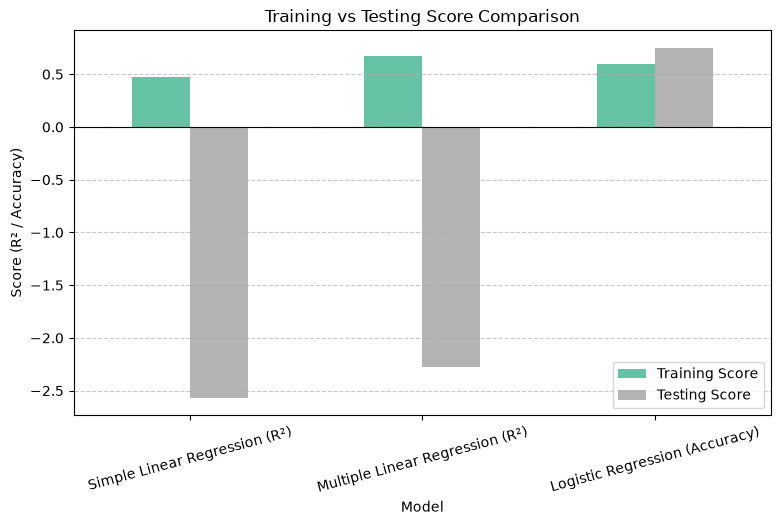

In [8]:
# Compute Predictions on Training Sets
y_train_pred_s = model_simple.predict(X_train_s)
y_train_pred_m = model_multi.predict(X_train_m)
y_train_pred_c = clf_model.predict(X_train_c)

# Build Comparison Table
train_vs_test = pd.DataFrame({
    'Model': ['Simple Linear Regression (R²)', 'Multiple Linear Regression (R²)', 'Logistic Regression (Accuracy)'],
    'Training Score': [
        r2_score(y_train_s, y_train_pred_s),
        r2_score(y_train_m, y_train_pred_m),
        accuracy_score(y_train_c, y_train_pred_c)
    ],
    'Testing Score': [
        r2_score(y_test_s, y_pred_s),
        r2_score(y_test_m, y_pred_m),
        accuracy_score(y_test_c, y_pred_c)
    ]
})

print("=== Training vs Testing Performance ===")
display(train_vs_test.round(4))

# Bar Chart Plot
train_vs_test.plot(x='Model', kind='bar', figsize=(9, 5),rot=15,colormap='Set2')
plt.title('Training vs Testing Score Comparison')
plt.ylabel('Score (R² / Accuracy)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Regression vs Classification Overview

### Model Performance Metrics